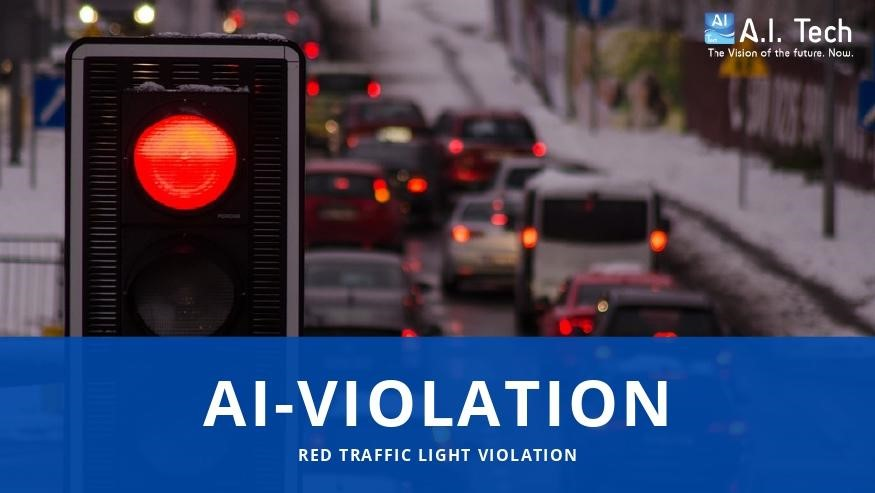

In [ ]:
import cv2
import numpy as np
import cvzone
import pygame
import telepot
from ultralytics import YOLO
import os

path = r"D:\Computer Vision\Detect-red-traffic-light-violations-using-opencv-and-yolov10-main"
os.chdir(path)

from tracker import Tracker


def process_frame(frame):
    # Define color ranges for Green and Red traffic lights in HSV
    lower_bound_green = np.array([58, 97, 222])
    upper_bound_green = np.array([179, 255, 255])

    lower_bound_red = np.array([0, 43, 184])
    upper_bound_red = np.array([56, 132, 255])

    frame_hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Masks for green and red colors
    mask_green = cv2.inRange(frame_hsv, lower_bound_green, upper_bound_green)
    mask_red = cv2.inRange(frame_hsv, lower_bound_red, upper_bound_red)

    combined_mask = cv2.bitwise_or(mask_green, mask_red)

    # Apply threshold
    _, final_mask = cv2.threshold(combined_mask, 254, 255, cv2.THRESH_BINARY)

    detected_label = None

    conts, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    for i in conts:
        if cv2.contourArea(i) > 50:
            x, y, w, h = cv2.boundingRect(i)

            cx = x + w // 2
            cy = y + h // 2

            if cx < 915:
                if cv2.countNonZero(mask_green[y:y+h, x:x+w]) > 0:
                    color = (0, 255, 0)  
                    text_color = (0, 255, 0)
                    label = "GREEN"
                elif cv2.countNonZero(mask_red[y:y+h, x:x+w]) > 0:
                    color = (0, 0, 255)
                    text_color = (0, 0, 255)
                    label = "RED"
            else:
                continue

            detected_label = label

            cv2.rectangle(frame, (894, 234), (934, 120), (255, 0, 0), 2)
            cvzone.putTextRect(frame , "Traffic Light" , (801, 102) , 2, 2 , colorT = text_color , colorR=(0,0,0))
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
            cv2.circle(frame, (cx, cy), 1, (255, 0, 0), -1)
            cv2.putText(frame, label, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, text_color, 2)

    return frame, detected_label



#  YOLOv10 model
model = YOLO("yolov10s.pt")

#  COCO classes
with open(r"coco.txt", "r") as df:
    classes = df.read().split("\n")

pygame.mixer.init()
pygame.mixer.music.load("alarm.wav")


#  Telegram bot
bot = telepot.Bot(token="7291158558:AAH1H3KhIxsCuYRfH3yQTiPvwDnCQewp_a8")
id_chat = "5045069081"

def send_photo_to_telegram(image_path):
    bot.sendPhoto(id_chat, open(image_path, 'rb'))


    
cap = cv2.VideoCapture(r"tr.mp4")

# Initialize tracker
tracker = Tracker()

area = [(274, 430), (840, 434), (836, 373), (322, 366)]

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Error loading video.")
        break

    frame = cv2.resize(frame, (1020, 700))

    processed_frame, detected_label = process_frame(frame)

    results = model(frame)

    lis = []
    
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            if int(box.cls[0]) < len(classes):
                name = classes[int(box.cls[0])]
                conf = box.conf[0] 

                if name in ["car"] and conf > 0.5:
                    lis.append([x1, y1, x2, y2])
                    bbox_id = tracker.update(lis)
                    for bb in bbox_id:
                        x1, y1, x2, y2, idd = bb

                        ww = x2 - x1
                        hh = y2 - y1

                        cx = int((x1 + x2) // 2)
                        cy = int((y1 + y2) // 2)

                       
                        cvzone.putTextRect(frame, f"Car, Conf:{conf * 100:.2f} %", (x1 -5 , y1 -15), scale=1, thickness=2, colorR=(0, 255, 0), colorT=(0, 0, 0))
                        cvzone.cornerRect(frame, (x1, y1, ww, hh), l=10, t=10, rt=2, colorR=(0, 0, 0), colorC=(0, 255, 0))

                        cv2.circle(frame, (cx, cy), 4, (255, 0, 0), -1)
                        
                        result = cv2.pointPolygonTest(np.array(area, np.int32), (cx, cy), False)

                        if result >= 0 and detected_label == "RED":
                            
                            cv2.polylines(frame, [np.array(area, np.int32)], True, (0, 0, 255), 2)

                            cvzone.putTextRect(frame, "This Car Violated The Traffic!", (x1, y1 + 30), scale=1.5, thickness=2, colorR=(0, 255, 0), colorT=(0, 0, 255))

                            cvzone.cornerRect(frame, (x1, y1, ww, hh), l=10, t=10, rt=2, colorR=(0, 0, 255), colorC=(0, 0, 255))

                            
                            if not pygame.mixer.music.get_busy():
                                pygame.mixer.music.play()

                            image_path = f"Car_Traffic_Violation_Detection.jpg"
                            cv2.imwrite(image_path, frame)

                            send_photo_to_telegram(image_path)

    
    cv2.polylines(frame, [np.array(area, np.int32)], True, (0, 255, 0), 2)

    cv2.imshow("Road Traffic Violation Detection", frame)

    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [ ]:
import cv2
import cvzone
import numpy as np
import time
from ultralytics import YOLO
import pygame
import telepot
import os

# Set the working directory to the path where the script and related files are located
path = r"D:\Computer Vision\wrong-way-driving-detection-yolov8-wrong-way-vehicle-detection-yolov8-traffic-management--main"
os.chdir(path)

# Define a function to capture mouse events
def points(event, x, y, flags, param):
    if event == cv2.EVENT_MOUSEMOVE:
        print(f"Mouse position: ({x}, {y})")

# Create a window and set the mouse callback function
cv2.namedWindow("Wrong Way Driving Detection")  # Ensure the window name matches
cv2.setMouseCallback("Wrong Way Driving Detection", points)  # Set callback for this window

# Load the video capture
cap = cv2.VideoCapture(r"wrongway.mp4")

# Load YOLO model (assuming you're using YOLOv8)
# You would need to load your model here
# model = YOLO("path_to_yolov8_model.pt")  # Uncomment and set the path to your model

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Resize the frame for consistent display size
    frame = cv2.resize(frame, (1020, 700))

    # Run detection (uncomment and modify as per your YOLO model's usage)
    # results = model(frame)

    # Display the frame
    cv2.imshow("Wrong Way Driving Detection", frame)

    # Exit loop if 'q' is pressed
    if cv2.waitKey(1) == ord("q"):
        break

# Release video capture and close windows
cap.release()
cv2.destroyAllWindows()

# Quit pygame if it was initialized (in case you added sounds or other functionalities)
# pygame.mixer.quit()
